In [1]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

WD masses in binary systems range from 0.8 - 1.14 solar masses, and avg radius is 0.01 solar radii
NS avg mass 1.4 solar masses, avg radius is 15km
BH masses (stellar-mass) 5-150 solar masses, (radius around 30 km for 10 solar masses)


In [2]:
N = 5000
m_wd = 0.63
m_s = 1.1
r_wd = 0.0133 * u.R_sun 
r_s = 1.0 * u.R_sun
a = 10 * u.R_sun
e = 0 #0.061
period = 683.267 
L_star = 1.0
L_wd = 0.001
t = np.linspace(0, (period*u.day).to(u.yr).value, N) * u.yr
d = 50 * u.pc
inc = 90 *u.deg

prob something with E calculation

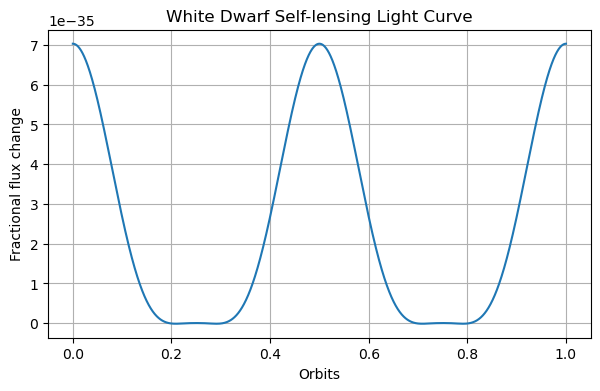

In [3]:
test1 = WDBinary(m_wd, r_wd, L_wd, m_s, r_s, L_star, e, a, d, t, inc=inc, period=period)
test1.plot_light_curve(t)

## MC Calcualtion ##

In [4]:
def einstein_radius_circ(M, a, D):
    r_E = np.sqrt((2 * G * M * a) / (c**2 * D * (D + a)))
    return (r_E * D).to(u.Rsun)
    
def transit_prob(r_E, r_star, a):
    return (r_E + r_star) / a

In [5]:
def sample_rstar_from_mstar(Mstar, N, sigma_logR=0.1):
    if Mstar.value < 1.0:
        alpha = 0.8
    elif Mstar.value < 10.0:
        alpha = 0.57
    else:
        alpha = 0.3

    Rmean = Mstar.value**alpha
    logR = np.log10(Rmean) + np.random.normal(0, sigma_logR, N)
    return 10**logR * u.Rsun

def sample_cosi(N):
    return np.random.uniform(0, 1, N)

def transit_condition(a, cosi, Rstar, rE):
    r = a * cosi

    if Rstar.size > 1:
        rE_arr = rE

        if rE.size == 1:
            rE_arr = np.ones(Rstar.size) * rE
        
        cond = Rstar + rE_arr

    return r < cond

In [6]:
def transit_prob_Mlens(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [7]:
def transit_prob_a(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [8]:
def transit_prob_Rstar(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [9]:
a_vals = np.logspace(-2, 1, 50) * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=0.6*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)


[4.7775e-01 4.1430e-01 3.6156e-01 3.1300e-01 2.7324e-01 2.3887e-01
 2.0619e-01 1.7806e-01 1.5353e-01 1.3516e-01 1.1726e-01 1.0108e-01
 8.8920e-02 7.6300e-02 6.5820e-02 5.7790e-02 5.0320e-02 4.3550e-02
 3.7920e-02 3.3110e-02 2.9020e-02 2.5180e-02 2.1690e-02 1.8740e-02
 1.6520e-02 1.4480e-02 1.2100e-02 1.0100e-02 9.7800e-03 8.2300e-03
 7.0900e-03 5.6800e-03 5.0200e-03 4.2100e-03 3.9200e-03 3.5500e-03
 2.7800e-03 2.6900e-03 2.5000e-03 1.9000e-03 1.5500e-03 1.6400e-03
 1.3800e-03 1.2300e-03 1.0300e-03 8.9000e-04 6.1000e-04 7.3000e-04
 6.1000e-04 4.6000e-04]
[47775 41430 36156 31300 27324 23887 20619 17806 15353 13516 11726 10108
  8892  7630  6582  5779  5032  4355  3792  3311  2902  2518  2169  1874
  1652  1448  1210  1010   978   823   709   568   502   421   392   355
   278   269   250   190   155   164   138   123   103    89    61    73
    61    46]
[ 0.01        0.01151395  0.01325711  0.01526418  0.01757511  0.0202359
  0.02329952  0.02682696  0.03088844  0.0355648   0.04094915  

Text(0.5, 0, 'a (AU)')

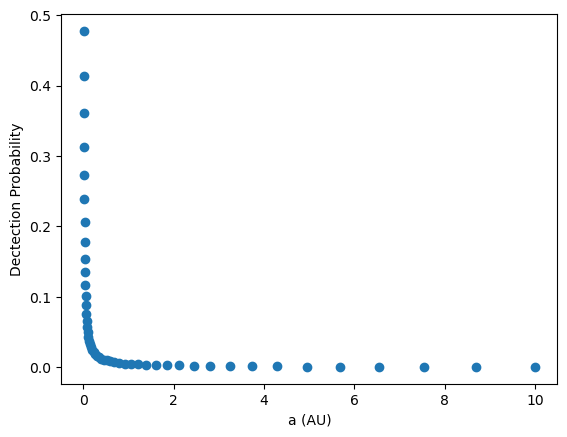

In [10]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

In [11]:
Mlens_vals = np.linspace(0.1, 10, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.kpc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.0047  0.00475 0.00452 0.00457 0.00487 0.00454 0.00459 0.00488 0.00445
 0.00495 0.00497 0.00467 0.00465 0.00503 0.00493 0.00471 0.00543 0.00474
 0.00464 0.00477 0.00501 0.00507 0.00474 0.00419 0.0049  0.0048  0.00502
 0.00487 0.00469 0.0045  0.00446 0.00507 0.00491 0.00484 0.00445 0.00458
 0.00496 0.0048  0.00523 0.00474 0.00485 0.00473 0.00505 0.00461 0.00457
 0.00478 0.00501 0.00492 0.00507 0.00485 0.00476 0.00481 0.00479 0.00472
 0.00468 0.00507 0.00465 0.00496 0.00539 0.00474 0.00486 0.00456 0.00476
 0.00524 0.00533 0.00481 0.00495 0.00493 0.00455 0.00492 0.00472 0.00498
 0.00507 0.00443 0.00501 0.00476 0.00482 0.00483 0.00481 0.00481 0.00554
 0.0048  0.00475 0.00479 0.00495 0.00476 0.0047  0.00491 0.00504 0.00444
 0.00518 0.00508 0.00549 0.0054  0.00452 0.00487 0.00501 0.005   0.0048
 0.0048  0.0049  0.005   0.00494 0.00496 0.0047  0.00479 0.00513 0.00461
 0.00474 0.00529 0.00476 0.0051  0.00489 0.00472 0.00518 0.00496 0.00505
 0.0051  0.00507 0.00499 0.00485 0.00476 0.00488 0.0

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

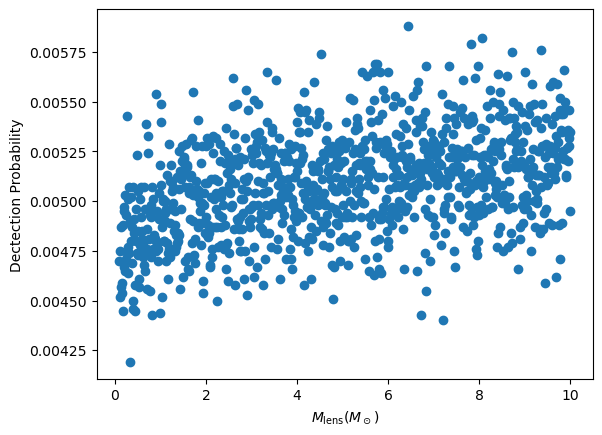

In [12]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [13]:
Mstar_vals = np.linspace(0.2, 5, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=M, Mlens=0.6*u.Msun, D=26.8*u.kpc)
           for M in Mstar_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mstar_vals)


[0.0013  0.00134 0.00142 0.00139 0.00168 0.00163 0.00165 0.0015  0.00161
 0.00166 0.00175 0.00155 0.00132 0.00202 0.00163 0.00156 0.0019  0.00181
 0.00197 0.00184 0.00179 0.00199 0.00179 0.00196 0.00188 0.00202 0.00219
 0.00202 0.00215 0.0022  0.00228 0.00231 0.00239 0.00253 0.00236 0.00235
 0.00232 0.00247 0.00248 0.0023  0.00231 0.00263 0.00235 0.00277 0.00229
 0.00239 0.00248 0.00268 0.00256 0.00257 0.00277 0.00252 0.00257 0.00274
 0.00264 0.00266 0.00267 0.00256 0.00288 0.00251 0.00275 0.00278 0.00245
 0.00276 0.00307 0.00277 0.00293 0.00315 0.00293 0.00317 0.00271 0.00311
 0.00322 0.0032  0.0031  0.00288 0.00313 0.00307 0.00321 0.00287 0.00335
 0.00331 0.00329 0.00312 0.00347 0.00312 0.00338 0.00326 0.0033  0.00348
 0.00349 0.00351 0.00344 0.00339 0.00322 0.00334 0.00356 0.0034  0.00336
 0.00359 0.00365 0.004   0.00298 0.00334 0.00372 0.00403 0.00344 0.00383
 0.00372 0.00372 0.00414 0.00359 0.0037  0.00391 0.00388 0.00376 0.00361
 0.00408 0.00407 0.00394 0.00426 0.00394 0.00411 0.

Text(0.5, 0, '$M_\\mathrm{*} (M_\\odot)$')

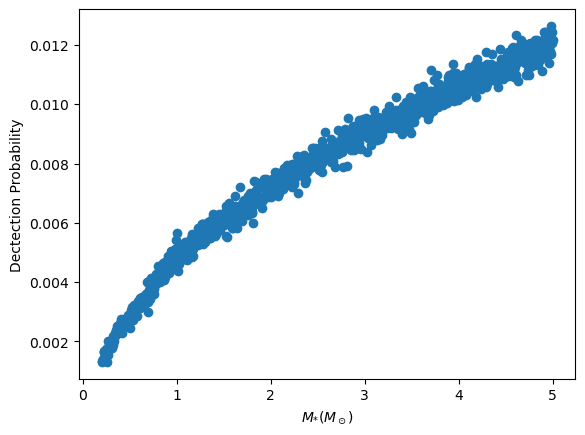

In [14]:
plt.scatter(Mstar_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{*} (M_\odot)$")

## BH SLB DETECABILITY RECALCULATION ##

In [15]:
def sample_bh_masses(N, m_min=5.0, m_max=50.0, alpha=2.3):
    inv = 1.0 - alpha
    c0 = m_min**inv
    c1 = m_max**inv
    r = np.random.rand(N)
    masses = (c0 + (c1 - c0)*r)**(1.0/inv)
    return masses

# replace your linspace with this:
Mlens_vals = sample_bh_masses(1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.kpc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.00543 0.00519 0.0054  0.00517 0.00532 0.00574 0.00498 0.00501 0.00542
 0.00543 0.0058  0.00511 0.00546 0.00511 0.0055  0.00488 0.00496 0.00522
 0.00525 0.00506 0.00516 0.00513 0.00478 0.00541 0.00486 0.00543 0.00528
 0.00533 0.00534 0.00536 0.00539 0.00485 0.005   0.00512 0.00522 0.00526
 0.00489 0.00532 0.00521 0.00519 0.00529 0.00505 0.00511 0.00513 0.00507
 0.00474 0.00536 0.00524 0.00547 0.00568 0.00476 0.00536 0.00533 0.00553
 0.005   0.00511 0.00552 0.00554 0.00558 0.00513 0.00522 0.00518 0.00522
 0.00492 0.00546 0.00532 0.00523 0.00541 0.00516 0.00483 0.00497 0.00532
 0.00478 0.00497 0.00512 0.00515 0.00573 0.00532 0.00574 0.00509 0.00523
 0.0051  0.00521 0.00517 0.00526 0.00509 0.00543 0.00553 0.00485 0.00553
 0.00531 0.00558 0.00512 0.00561 0.00515 0.0054  0.00495 0.00531 0.00541
 0.00491 0.00468 0.00537 0.00541 0.00506 0.00503 0.00523 0.00544 0.00511
 0.00572 0.00486 0.00533 0.00517 0.00542 0.0052  0.00525 0.00522 0.00521
 0.00504 0.00508 0.00502 0.00489 0.00534 0.00528 0.

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

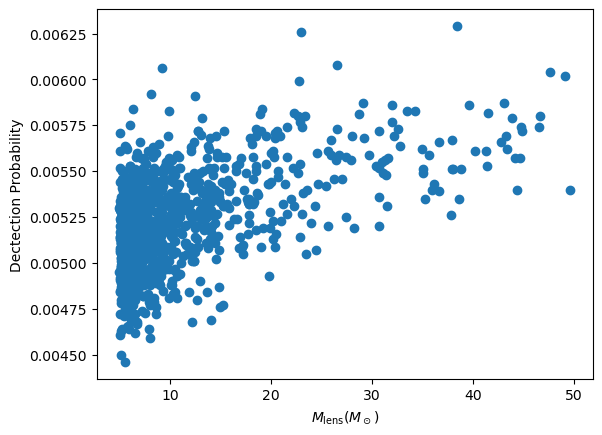

In [16]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [17]:
a_vals = []
while len(a_vals) < 100:
    x = np.random.normal(4.96, 2.5, 100)
    a_vals = np.concatenate([a_vals, x[(x>=1.40)&(x<=16.55)]])
a_vals = np.array(a_vals[:100]) * u.AU

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=10*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)

[0.00097 0.00178 0.00098 0.00113 0.00061 0.00088 0.00182 0.00077 0.00072
 0.00119 0.00089 0.00091 0.00263 0.00092 0.00301 0.00106 0.00116 0.00066
 0.00087 0.00113 0.00122 0.00102 0.00133 0.00098 0.00365 0.00229 0.00104
 0.00067 0.00367 0.0007  0.00106 0.00058 0.00103 0.00087 0.0009  0.00062
 0.0009  0.0016  0.00118 0.00104 0.00191 0.00072 0.00208 0.00108 0.0009
 0.00229 0.00153 0.00126 0.00133 0.00071 0.00155 0.00122 0.00123 0.00101
 0.00072 0.00093 0.00356 0.00152 0.00282 0.00296 0.00116 0.00064 0.00091
 0.00107 0.00093 0.00162 0.00057 0.00294 0.00122 0.00142 0.0024  0.00117
 0.00306 0.00085 0.00116 0.00207 0.00277 0.00117 0.00099 0.00099 0.00104
 0.00098 0.00129 0.00084 0.00066 0.0015  0.00123 0.00175 0.0008  0.00183
 0.00071 0.0017  0.00104 0.00161 0.00308 0.00075 0.00073 0.00135 0.00202
 0.00124]
[ 97 178  98 113  61  88 182  77  72 119  89  91 263  92 301 106 116  66
  87 113 122 102 133  98 365 229 104  67 367  70 106  58 103  87  90  62
  90 160 118 104 191  72 208 108  90 229 1

Text(0.5, 0, 'a (AU)')

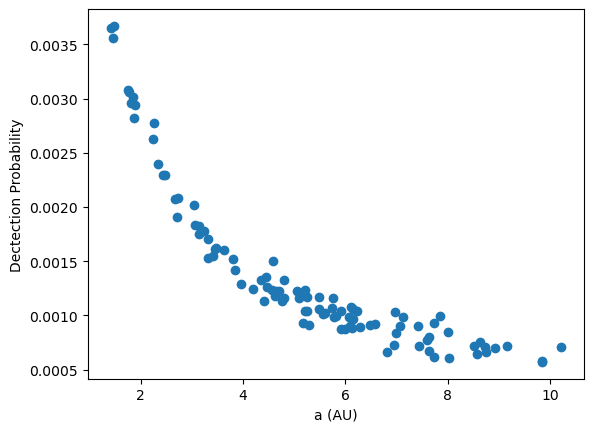

In [18]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

## NS SLB DETECTABILITY CALCULATION ##

In [19]:
def sample_ns_masses(N, mu=1.4, sigma=0.15, m_min=1.0, m_max=2.3):
    """
    Sample neutron star masses from a truncated normal distribution.
    Units: solar masses.
    """
    masses = np.random.normal(mu, sigma, N)

    # reject unphysical values
    mask = (masses < m_min) | (masses > m_max)
    while np.any(mask):
        masses[mask] = np.random.normal(mu, sigma, np.sum(mask))
        mask = (masses < m_min) | (masses > m_max)

    return masses

Mlens_vals = sample_ns_masses(1000) * u.Msun
a = 0.021 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.kpc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.22897 0.22855 0.2284  0.22897 0.22941 0.22987 0.22913 0.22907 0.22711
 0.22852 0.22907 0.22997 0.23094 0.22991 0.22724 0.2285  0.22984 0.22804
 0.23015 0.22876 0.22815 0.22849 0.22904 0.2273  0.22995 0.22794 0.22789
 0.22847 0.22789 0.23032 0.22923 0.22912 0.22875 0.2295  0.22901 0.22819
 0.22903 0.22897 0.2285  0.2302  0.22862 0.22899 0.23027 0.22672 0.22945
 0.22972 0.22886 0.22958 0.22657 0.22781 0.22868 0.22817 0.22884 0.22888
 0.22808 0.23018 0.22773 0.22842 0.22877 0.2306  0.22775 0.22751 0.22959
 0.2271  0.22961 0.22904 0.22768 0.22992 0.22855 0.22842 0.22822 0.22954
 0.22798 0.22938 0.22781 0.22848 0.23235 0.22709 0.23065 0.23112 0.22766
 0.23145 0.22993 0.22756 0.2294  0.22737 0.22949 0.22748 0.23077 0.22724
 0.23166 0.22791 0.22921 0.22959 0.22691 0.22756 0.22959 0.22735 0.229
 0.22827 0.22786 0.22821 0.22904 0.23    0.22802 0.22761 0.22805 0.23011
 0.23006 0.22984 0.22751 0.22756 0.23067 0.22964 0.22742 0.22936 0.22715
 0.23054 0.22828 0.22921 0.22674 0.2278  0.22852 0.22

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

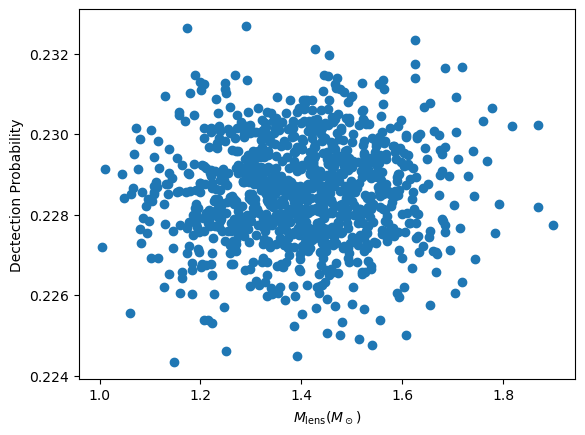

In [20]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [21]:
a_vals = []
while len(a_vals) < 100:
    x = np.random.normal(0.02, 0.008, 1000)  # AU
    a_vals = np.concatenate([a_vals, x[(x>=0.003)&(x<=0.08)]])
a_vals = np.array(a_vals[:100]) * u.AU

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=1.4*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)

[0.18672 0.36479 0.262   0.20464 0.1712  0.31028 0.23688 0.14451 0.21461
 0.17324 0.28706 0.27188 0.38196 0.3863  0.2534  0.39331 0.2218  0.19247
 0.16561 0.12763 0.28511 0.15205 0.1926  0.16283 0.18475 0.16948 0.18731
 0.27322 0.22343 0.24002 0.90076 0.23381 0.31972 0.16942 0.2864  0.25697
 0.24881 0.58966 0.17383 0.16501 0.22868 0.15044 0.91581 0.17905 0.52678
 0.52658 0.23001 0.26692 0.5143  0.26575 0.19711 0.23485 0.29141 0.13753
 0.55605 0.17881 0.22826 0.20116 0.28386 0.2064  0.1816  0.29337 0.21192
 0.18069 0.16933 0.21663 0.21804 0.20023 0.12778 0.27871 0.19293 0.27699
 0.21805 0.1011  0.22828 0.37111 0.28827 0.21196 0.22112 0.28362 0.14502
 0.57504 0.29472 0.23924 0.42886 0.16547 0.90307 0.26667 0.17783 0.16724
 0.29327 0.28528 0.39636 0.26742 0.35149 0.30591 0.32437 0.20179 0.4031
 0.25423]
[18672 36479 26200 20464 17120 31028 23688 14451 21461 17324 28706 27188
 38196 38630 25340 39331 22180 19247 16561 12763 28511 15205 19260 16283
 18475 16948 18731 27322 22343 24002 90076

Text(0.5, 0, 'a (AU)')

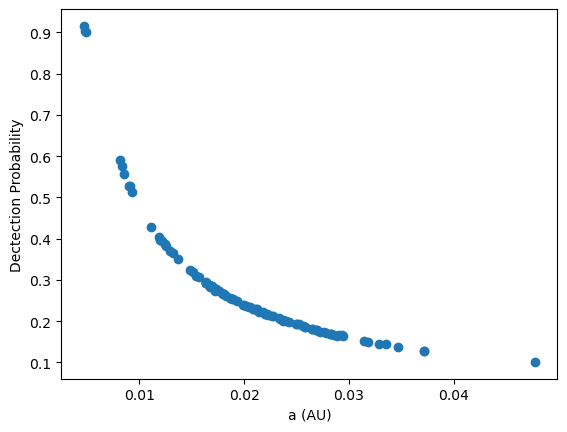

In [22]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

## WD SLB DETECTABILITY CALCULATION ##

In [23]:
a_vals = []
while len(a_vals) < 100:
    x = np.random.normal(0.46, 0.05, 1000)
    a_vals = np.concatenate([a_vals, x[(x>=0.05)&(x<=1.3)]])
a_vals = np.array(a_vals[:100]) * u.AU

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=0.63*u.Msun, D=26.8*u.kpc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)

[0.00902 0.01138 0.01206 0.01045 0.00996 0.01044 0.01056 0.01054 0.01138
 0.0113  0.00948 0.0101  0.00805 0.01023 0.00991 0.01015 0.01018 0.01132
 0.00802 0.00867 0.00966 0.01064 0.01184 0.01019 0.0108  0.00926 0.01022
 0.01069 0.01047 0.01058 0.01269 0.01092 0.00988 0.01027 0.01099 0.01098
 0.01219 0.01147 0.0099  0.01205 0.0083  0.01062 0.01067 0.00975 0.00915
 0.01127 0.01073 0.01015 0.00876 0.00997 0.01311 0.01009 0.01307 0.00923
 0.01096 0.01075 0.00949 0.00968 0.01004 0.00977 0.01069 0.0095  0.01134
 0.01119 0.00968 0.01025 0.01303 0.01353 0.00944 0.01004 0.01059 0.01053
 0.01044 0.01146 0.00929 0.00959 0.00968 0.00994 0.00893 0.00929 0.01205
 0.00926 0.00945 0.01033 0.01191 0.01164 0.01147 0.01129 0.01194 0.01055
 0.01197 0.00999 0.01015 0.01041 0.01167 0.00992 0.01251 0.01032 0.00941
 0.00998]
[ 902 1138 1206 1045  996 1044 1056 1054 1138 1130  948 1010  805 1023
  991 1015 1018 1132  802  867  966 1064 1184 1019 1080  926 1022 1069
 1047 1058 1269 1092  988 1027 1099 1098 1219

Text(0.5, 0, 'a (AU)')

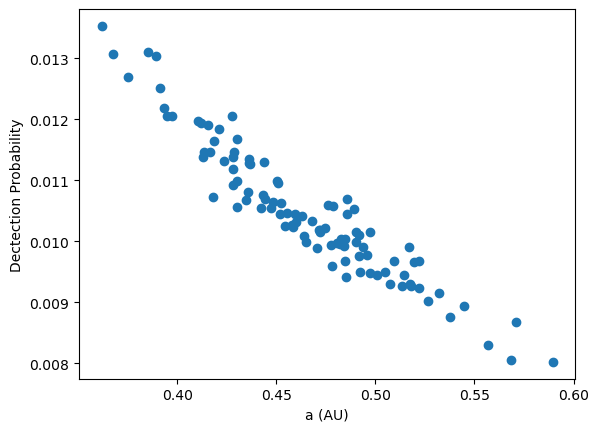

In [24]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")